In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta
import plotly.io as pio

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-03-17 14:08:29,576][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-03-17 14:08:29,955][INFO]: DataJoint 0.14.4 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from workflow.pipeline import ephys, analysis, culture

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


**Fitting Oscillations and One-Over-F (FOOOF)**

FOOOF is an open‑source Python toolbox that models neural power spectra as the combination of a smooth aperiodic “1/f” background and distinct oscillatory peaks. By explicitly separating these components, it provides clean, interpretable parameters for both the background activity (slope, offset) and each oscillation (center frequency, power, bandwidth), rather than conflating them in raw power values. This separation is important because many experimental or clinical effects that look like changes in “oscillations” are actually driven by shifts in the aperiodic component, so FOOOF helps clarify whether observed spectral differences reflect true rhythmic changes, background changes, or both.

Key paper: `Donoghue, T., et. al. (2020). Parameterizing neural power spectra into periodic and aperiodic components. Nature Neuroscience, 23(12), 1655–1665. https://doi.org/10.1038/s41593-020-00744-x`

**FOOOF-based BOSC, i.e., a BOSC (Better OSCillation detection)**

fBOSC (FOOOF + BOSC) is a burst‑detection framework that plugs the FOOOF spectral parametrization into the classic BOSC algorithm to define oscillatory bursts against a more accurate 1/f background. It uses FOOOF to model and remove the aperiodic 1/f component—optionally including a knee—so that burst thresholds are set relative to a background that is not distorted by large peaks or non‑linear spectra. This tight relationship means FOOOF handles the spectral parametrization, while BOSC handles the time‑domain burst detection, giving fBOSC more reliable estimates of when and where true oscillatory bursts occur. fBOSC is important because it improves 1/f fitting, especially in data with knees and strong peaks, leading to more valid burst detection across frequencies like theta and alpha and reducing artifactual differences that come purely from background slope changes.

Key paper: `Seymour, R., Alexander, N., Maguire, E. (2022). Robust estimation of 1/f activity improves oscillatory burst detection. European Journal of Neuroscience, 55(6), 1726-1741. https://doi.org/10.1111/ejn.15656`

In [5]:
analysis.FOOOFParamset()

fooof_param_idx Unique identifier for the FOOOF parameter set,"peak_width_limits Lower and upper bounds on peak widths in Hz. e.g. [1, 12]",max_n_peaks Maximum number of peaks the model can fit. e.g. 6,min_peak_height Minimum absolute height of a peak above the aperiodic component. e.g. 0.1,peak_threshold Relative threshold that candidate peaks must exceed to be included. e.g. 2.0,"aperiodic_mode Form of the aperiodic fit. e.g. 'fixed', 'knee'"
0,=BLOB=,6,0.1,2.0,fixed
1,=BLOB=,3,0.05,3.5,fixed
2,=BLOB=,3,0.05,3.5,knee


In [7]:
analysis.FBOSCParamset()

fbosc_param_idx Unique identifier for the fBOSC parameter set,dt Time resolution in seconds (for each epoch). e.g. 10,detection_thresh Chi-squared threshold for peak detection. (between 0 and 1)
0,10.0,0.99
1,10.0,0.95
2,30.0,0.99
3,10.0,0.999


FOOOF / BOSC analysis is downstream from `EphysSession`. Before running this notebook, ensure that the relevant `EphysSession` data has been processed and is available in the database. 

If there is no existing `EphysSession` data for the desired session, refer to the `CREATE_new_session.ipynb` notebook to create it first.

In [7]:
# Input necessary information
organoid_id = "O09"
start_time = datetime(2023, 5, 4, 4, 12, 52)
end_time = datetime(2023, 5, 4, 4, 27, 52)

ephys_key = (ephys.EphysSession() & {'organoid_id': organoid_id, 'start_time': start_time}).fetch1('KEY')
ephys.EphysSession & ephys_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,session_type
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,both


Our FOOOF pipeline is organized by the manual table `FOOOFandBOSCSession` (which requires `EphysSession`, `FOOOFParamset`, and `BOSCParamset`). After creating a new entry in this table, the downstream analysis tables `FOOOFAnalysis` and `BOSCAnalysis` can be populated (automically with the cloud worker or manually on a local device).

In [8]:
key = {
    **ephys_key,
    "fooof_param_idx": 2,
    "fbosc_param_idx": 2,
    "start_freq": 2,
    "end_freq": 300,
    "analysis_electrodes": list(range((culture.NumElectrodesInside & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes")))  
}

analysis.FOOOFandFBOSCSession.insert1(key, skip_duplicates=True)

_ = key.pop("analysis_electrodes")
analysis.FOOOFandFBOSCSession & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,fooof_param_idx Unique identifier for the FOOOF parameter set,fbosc_param_idx Unique identifier for the fBOSC parameter set,start_freq Start frequency for FOOOF fitting,end_freq End frequency for FOOOF fitting,"analysis_electrodes List of electrodes to be averaged for analysis (if empty, will average across all electrodes)"
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,2,2,2.0,300.0,=BLOB=


OPTIONAL: Manually populate the analysis tables after creating the session entry.

In [9]:
analysis.FOOOFAnalysis.populate(key)

analysis.FOOOFAnalysis & key

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\plotly\matplotlylib\renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.



organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,fooof_param_idx Unique identifier for the FOOOF parameter set,fbosc_param_idx Unique identifier for the fBOSC parameter set,start_freq Start frequency for FOOOF fitting,end_freq End frequency for FOOOF fitting,spec_param_idx Reference to SpectrogramParamset,plot Plot of FOOOF fit (as json),summary_params FOOOF parameters over entire session,frequency Frequency values for spectrogram,oscillatory_activity spectrogram power relative to aperiodic fit (over entire session),aperiodic_offset Aperiodic offset over time,aperiodic_knee Aperiodic knee over time,aperiodic_exponent Aperiodic exponent over time,mean_absolute_error Mean absolute error of FOOOF fit over time,r_squared R^2 of FOOOF fit over time
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,2,2,2.0,300.0,2,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=


The master table `FOOOFAnalysis` contains three key metrics:
1) FOOOF fit across the entire session (averaged across all channels and time epochs)
    - Plot containing the average power spectrum with FOOOF fit overlayed
    - All parameters able to be extracted using the FOOOF pipeline (recently renamed specparam.SpectralModel)
2) Aperiodic metrics for each time epoch (averaged across channels)
    - Time series of aperiodic parameters (exponent, offset)
        - Offset = overall power level (similar to broadband power)
        - Knee = frequency at which 1/f slope bends (if applicable)
        - Exponent = steepness of 1/f slope (related to E/I balance)
3) Goodness of fit metrics for each time epoch (averaged across channels)
    - Time series of R² and MAE values indicating how well FOOOF modeled the power spectrum in each epoch 
        - R² = unitless proportion of variance explained by the FOOOF model (higher is better) 
        - MAE = mean absolute error between the FOOOF model and actual power spectrum (lower is better)

1) **FOOOF fit across the entire session:**

In [11]:
# print summary plot
# Plot FOOOF fit
plot_object = (analysis.FOOOFAnalysis & key).fetch1("plot")

fig = pio.from_json(plot_object)

# add title to pio figure
fig.update_layout(title='FOOOF Analysis of LFP Power Spectrum')


fig.show()

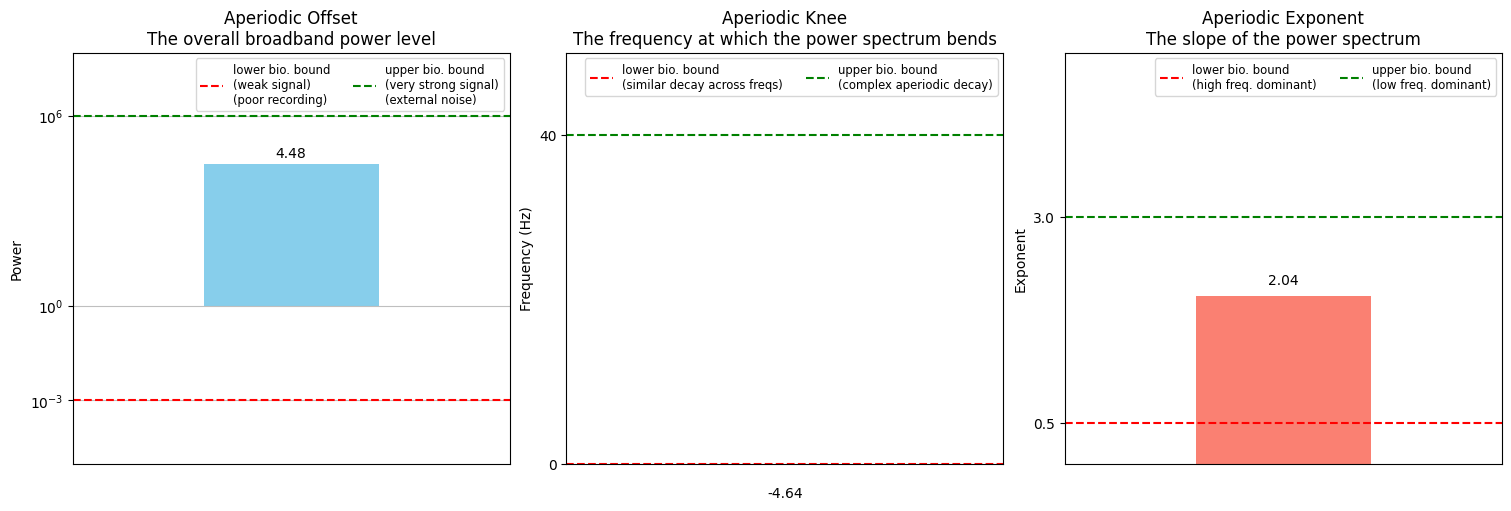

In [12]:
# plot summary aperiodic parameters

# fetch parameters
params = (analysis.FOOOFAnalysis & key).fetch1("summary_params")
aperiodic_params = params['aperiodic_params']

# plot aperiodic parameters
offset, knee, exponent = aperiodic_params
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
barwidth = 0.8

# biologically relevant bounds
offset_bounds = (-3, 6)
knee_bounds = (0, 40)
exponent_bounds = (.5, 3)

ax[0].bar([''], [offset], width=barwidth, color='skyblue')
ax[0].text(0, offset + 0.1, f"{offset:.2f}", ha='center', va='bottom')
ax[0].axhline(y=offset_bounds[0], color='r', linestyle='--', label='lower bio. bound\n(weak signal)\n(poor recording)')
ax[0].axhline(y=offset_bounds[1], color='g', linestyle='--', label='upper bio. bound\n(very strong signal)\n(external noise)')

ax[0].set_title('Aperiodic Offset\nThe overall broadband power level')
ax[0].set_ylabel('Power')
ax[0].set_xticks([])
ax[0].set_yticks([offset_bounds[0], 0, offset_bounds[1]], labels=[fr"$10^{{{offset_bounds[0]}}}$", r"$10^0$", fr"$10^{offset_bounds[1]}$"])
ax[0].set_xlim([-1, 1])
ax[0].set_ylim([min(offset_bounds[0]-2, np.floor(offset*.7)), max(offset_bounds[1]+2, np.ceil(offset*1.3))])
ax[0].legend(loc='upper right', fontsize='small', ncol=2)
ax[0].grid(True, alpha=0.8)

ax[1].bar([''], [knee], width=barwidth, color='lightgreen')
ax[1].text(0, knee + 0.1, f"{knee:.2f}", ha='center', va='bottom')
ax[1].axhline(y=knee_bounds[0], color='r', linestyle='--', label='lower bio. bound\n(similar decay across freqs)')
ax[1].axhline(y=knee_bounds[1], color='g', linestyle='--', label='upper bio. bound\n(complex aperiodic decay)')

ax[1].set_title('Aperiodic Knee\nThe frequency at which the power spectrum bends')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_xticks([])
ax[1].set_yticks(knee_bounds)
ax[1].set_xlim([-1, 1])
ax[1].set_ylim([0, np.max([knee_bounds[1]+10, np.ceil(knee*1.3)])])
ax[1].legend(loc='upper right', fontsize='small', ncol=2)

ax[2].bar([''], [exponent], width=barwidth, color='salmon')
ax[2].text(0, exponent + 0.1, f"{exponent:.2f}", ha='center', va='bottom')
ax[2].axhline(y=exponent_bounds[0], color='r', linestyle='--', label='lower bio. bound\n(high freq. dominant)')
ax[2].axhline(y=exponent_bounds[1], color='g', linestyle='--', label='upper bio. bound\n(low freq. dominant)')

ax[2].set_title('Aperiodic Exponent\nThe slope of the power spectrum')
ax[2].set_ylabel('Exponent')
ax[2].set_xticks([])
ax[2].set_yticks(exponent_bounds)
ax[2].set_xlim([-1, 1])
ax[2].set_ylim([0, np.max([exponent_bounds[1]+2, np.ceil(exponent*1.3)])])
ax[2].legend(loc='upper right', fontsize='small', ncol=2)


plt.show()

In [14]:
# plot summary aperiodic parameters

# fetch parameters
params = (analysis.FOOOFAnalysis & key).fetch1("summary_params")
peak_params = params['peak_params']

# account for no peaks detected
if np.any(np.isnan(peak_params[0])):
    raise SystemExit("No peaks detected in the power spectrum.")

# get peak metrics
center_freqs, peak_powers, bandwidths = peak_params.T
num_peaks = len(center_freqs)

# get biologically relevant bounds
center_freq_bounds = (1, 200) # Hz
peak_power_bounds = (0.05, 1)  # Power (log scale above aperiodic)
bandwidth_bounds = (2, 20)   # Hz (2*std of Gaussian)

# plot peak metrics
fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharex=True)
barwidth = 0.8
x = np.arange(num_peaks)

ax[0].bar(x, center_freqs, width=barwidth, color='skyblue')
for i, cf in enumerate(center_freqs):
    ax[0].text(i, cf + 0.1, f"{cf:.2f}", ha='center', va='bottom')
ax[0].axhline(y=center_freq_bounds[0], color='r', linestyle='--', label='lower bio. bound\nlow freq peak')
ax[0].axhline(y=center_freq_bounds[1], color='g', linestyle='--', label='upper bio. bound\nhigh freq peak')

ax[0].set_title('Center Frequencies\nThe position of oscillatory peaks')
ax[0].set_ylabel('Frequency (Hz)')
ax[0].set_xticks(x)
ax[0].set_yticks([center_freq_bounds[0], 0, center_freq_bounds[1]])
ax[0].set_xlim([-1, num_peaks])
ax[0].set_ylim([0, np.max([center_freq_bounds[1]+20, np.ceil(np.max(center_freqs)*1.3)])])
ax[0].legend(loc='upper right', fontsize='small', ncol=2)

ax[1].bar(x, peak_powers, width=barwidth, color='lightgreen')
for i, pp in enumerate(peak_powers):
    ax[1].text(i, pp + 0.1, f"{pp:.2f}", ha='center', va='bottom')
ax[1].axhline(y=peak_power_bounds[0], color='r', linestyle='--', label='low power peak\n(potential noise)')
ax[1].axhline(y=peak_power_bounds[1], color='g', linestyle='--', label='high power peak\n(potential artifact)')

ax[1].set_title('Peak Powers\nThe height of oscillatory peaks above aperiodic')
ax[1].set_ylabel('Power (above aperiodic)')
ax[1].set_xticks(x)
ax[1].set_yticks(peak_power_bounds, labels=[fr"$10^{{{peak_power_bounds[0]}}}$", fr"$10^{peak_power_bounds[1]}$"])
ax[1].set_xlim([-1, num_peaks])
ax[1].set_ylim([0, np.max([peak_power_bounds[1]+2, np.ceil(np.max(peak_powers)*1.3)])])
ax[1].legend(loc='upper right', fontsize='small', ncol=2)

ax[2].bar(x, bandwidths, width=barwidth, color='salmon')
for i, bw in enumerate(bandwidths):
    ax[2].text(i, bw + 0.1, f"{bw:.2f}", ha='center', va='bottom')
ax[2].axhline(y=bandwidth_bounds[0], color='r', linestyle='--', label='narrow peak\n(potential noise)')
ax[2].axhline(y=bandwidth_bounds[1], color='g', linestyle='--', label='wide peak\n(potential aperiodic misfit)')

ax[2].set_title('Bandwidths\nThe width of oscillatory peaks')
ax[2].set_ylabel('Bandwidth (Hz)')
ax[2].set_xticks(x)
ax[2].set_yticks(bandwidth_bounds)
ax[2].set_xlim([-1, num_peaks])
ax[2].set_ylim([0, np.max([bandwidth_bounds[1]+5, np.ceil(np.max(bandwidths)*1.3)])])
ax[2].legend(loc='upper right', fontsize='small', ncol=2)


plt.show()

SystemExit: No peaks detected in the power spectrum.

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning:

To exit: use 'exit', 'quit', or Ctrl-D.



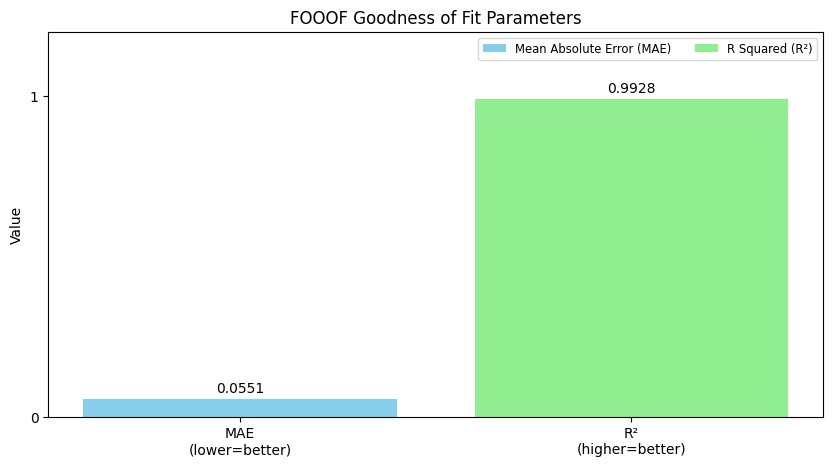

In [15]:
# plot summary goodness of fit parameters

# fetch parameters
params = (analysis.FOOOFAnalysis & key).fetch1("summary_params")
gof_params = params['metrics']

mae = gof_params['error_mae']
r_squared = gof_params['gof_rsquared']

# plot goodness of fit parameters
fig, ax = plt.subplots(figsize=(10, 5))
barwidth = 0.8
x = np.arange(2)

ax.bar(x[0], mae, width=barwidth, color='skyblue', label='Mean Absolute Error (MAE)')
ax.text(x[0], mae + 0.01, f"{mae:.4f}", ha='center', va='bottom')

ax.bar(x[1], r_squared, width=barwidth, color='lightgreen', label='R Squared (R²)')
ax.text(x[1], r_squared + 0.01, f"{r_squared:.4f}", ha='center', va='bottom')

ax.set_title('FOOOF Goodness of Fit Parameters')
ax.set_xticks(x, labels=['MAE\n(lower=better)', 'R²\n(higher=better)'])
ax.set_yticks([0, 1])
ax.set_ylabel('Value')
ax.set_ylim([0, 1.2])
ax.legend(loc='upper right', fontsize='small', ncol=2)

plt.show()

2) **Aperiodic dynamics across session**

Aperiodic metrics change over time, reflecting shifts in the brain's background activity. Here, we visualize how the aperiodic offset and exponent evolve across the session, averaged over all channels. These time series can reveal important dynamics in neural activity, such as changes in overall excitability (offset), at which frequency the 1/f slope bends (knee), and the balance of excitation and inhibition (exponent).

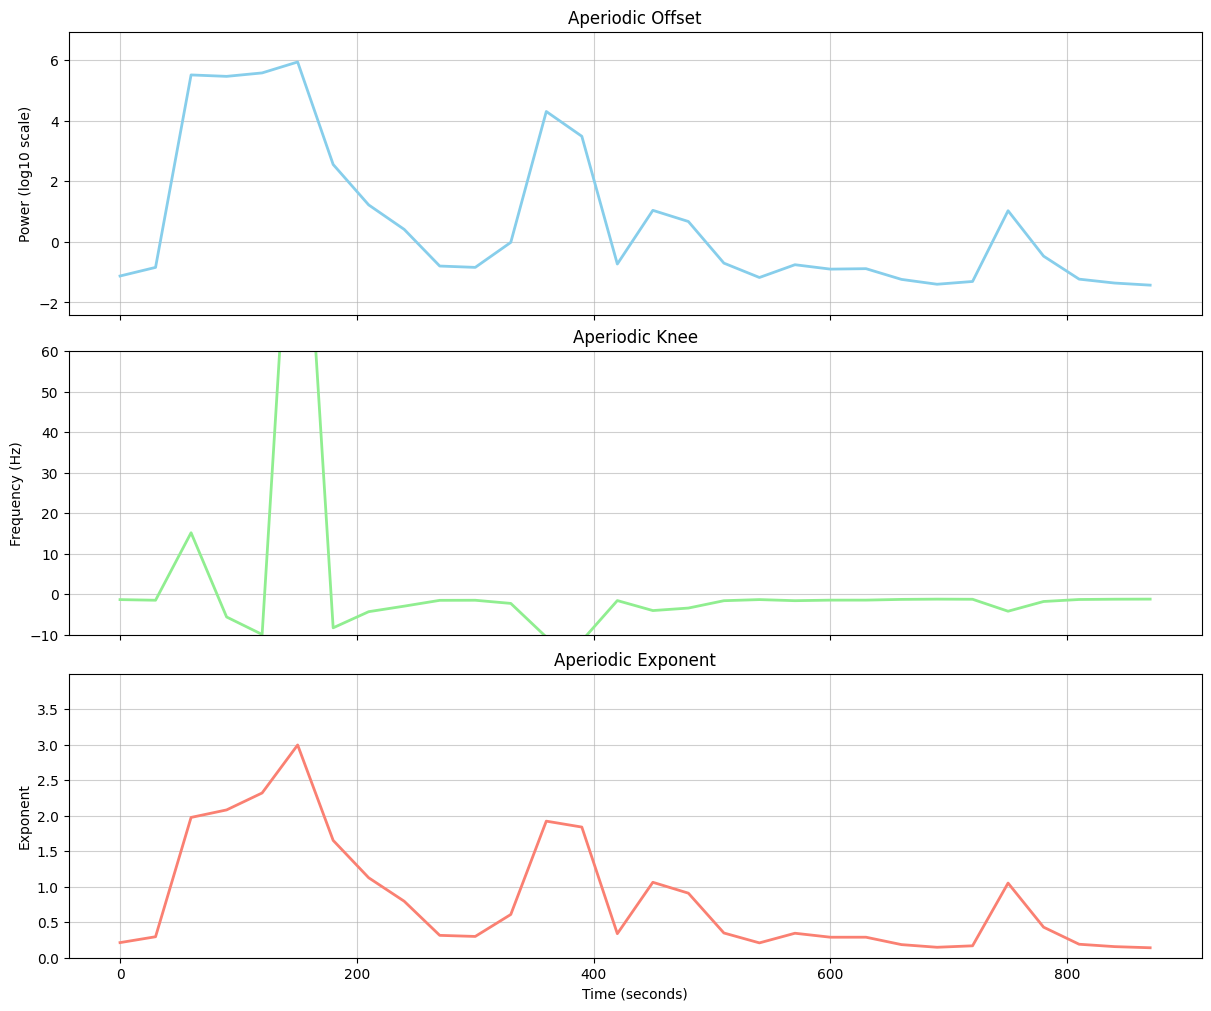

In [16]:
# fetch time-resolved aperiodic parameters
offset, knee, exponent = (analysis.FOOOFAnalysis & key).fetch1("aperiodic_offset", "aperiodic_knee", "aperiodic_exponent")

# get time vector
dt = (analysis.FBOSCParamset & key).fetch1("dt")
start_time, end_time = (analysis.FOOOFandFBOSCSession & key).fetch1("start_time", "end_time")
T = (end_time - start_time).total_seconds()
time_vector = np.arange(0, T, dt)

# plot time-resolved aperiodic parameters
fig, ax = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True, sharex=True)

# aperiodic offset
ax[0].plot(time_vector, offset, color='skyblue', linewidth=2, alpha=1)
ax[0].set_title('Aperiodic Offset')
ax[0].set_ylabel('Power (log10 scale)')
ax[0].grid(True, alpha=0.6)
ax[0].set_ylim([max([np.min(offset)-1, offset_bounds[0]-2]), min([np.max(offset)+1, offset_bounds[1]+2])])

# aperiodic knee
ax[1].plot(time_vector, knee, color='lightgreen', linewidth=2, alpha=1)
ax[1].set_title('Aperiodic Knee')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].grid(True, alpha=0.6)
ax[1].set_ylim([-10, min([np.max(knee)+5, knee_bounds[1]+20])])


# aperiodic exponent
ax[2].plot(time_vector, exponent, color='salmon', linewidth=2, alpha=1)
ax[2].set_title('Aperiodic Exponent')
ax[2].set_ylabel('Exponent')
ax[2].set_xlabel('Time (seconds)')
ax[2].grid(True, alpha=0.6)
ax[2].set_ylim([0, min([np.max(exponent)+1, exponent_bounds[1]+2])])

plt.show()

3) **Goodness of fit dynamics across session**

The model fit can change over time, especially if the underlying neural activity is non-stationary. Here, we plot the R² and MAE values across the session, averaged over all channels. Monitoring these metrics helps assess the reliability of the FOOOF fits in each epoch, ensuring that burst detection is based on accurate spectral modeling.

**NOTE:** We expect the fit to be worse when extracting time epochs. Power spectrums averaged over longer time periods (e.g., entire sessions) tend to be smoother and easier to fit than those from shorter epochs, which can be noisier and more variable.

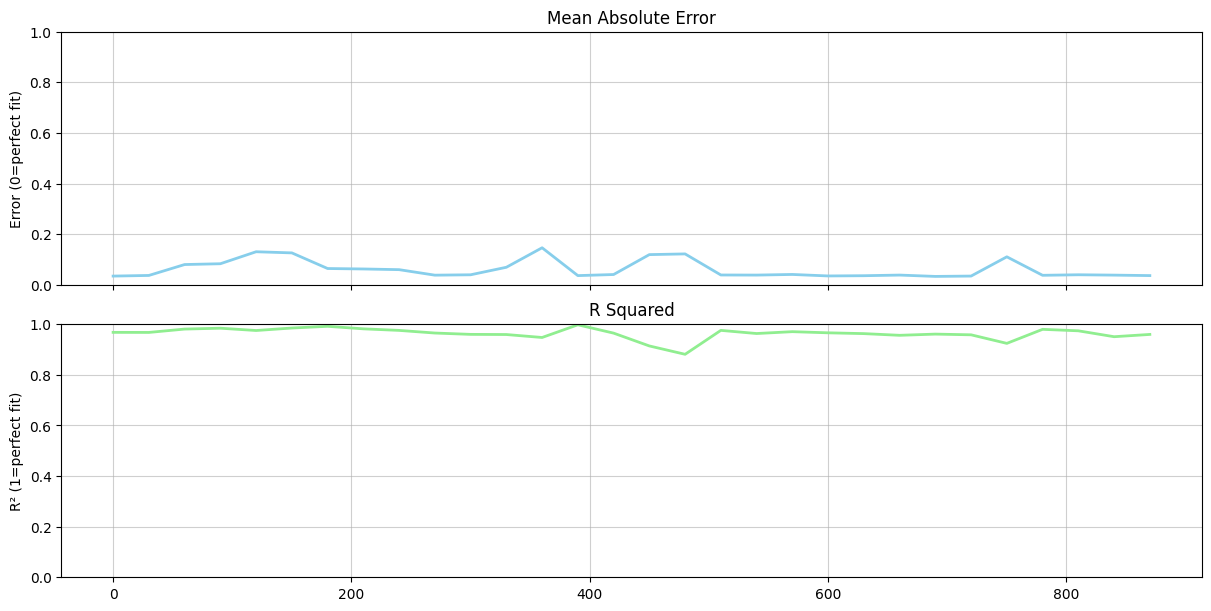

In [17]:
# fetch time-resolved aperiodic parameters
mae, r_squared = (analysis.FOOOFAnalysis & key).fetch1("mean_absolute_error", "r_squared")

# get time vector
dt = (analysis.FBOSCParamset & key).fetch1("dt")
start_time, end_time = (analysis.FOOOFandFBOSCSession & key).fetch1("start_time", "end_time")
T = (end_time - start_time).total_seconds()
time_vector = np.arange(0, T, dt)

# plot time-resolved aperiodic parameters
fig, ax = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True, sharex=True)

# mean absolute error
ax[0].plot(time_vector, mae, color='skyblue', linewidth=2, alpha=1)
ax[0].set_title('Mean Absolute Error')
ax[0].set_ylabel('Error (0=perfect fit)')
ax[0].grid(True, alpha=0.6)
ax[0].set_ylim([0, 1])

# r squared
ax[1].plot(time_vector, r_squared, color='lightgreen', linewidth=2, alpha=1)
ax[1].set_title('R Squared')
ax[1].set_ylabel('R² (1=perfect fit)')
ax[1].grid(True, alpha=0.6)
ax[1].set_ylim([0, 1])



plt.show()

The part table `FOOOFAnalysis.BOSCAnalysis` contains the results of the BOSC burst detection using the FOOOF-derived 1/f background. Oscillatory activity is quantified by burst times, or epochs that contain oscillatory activity exceeding a (chi-squared based) threshold relative to the aperiodic fit.

This table contains oscillatory burst times (based on epochs) for each of the frequency bands defined in `analysis.SpectralBand`.

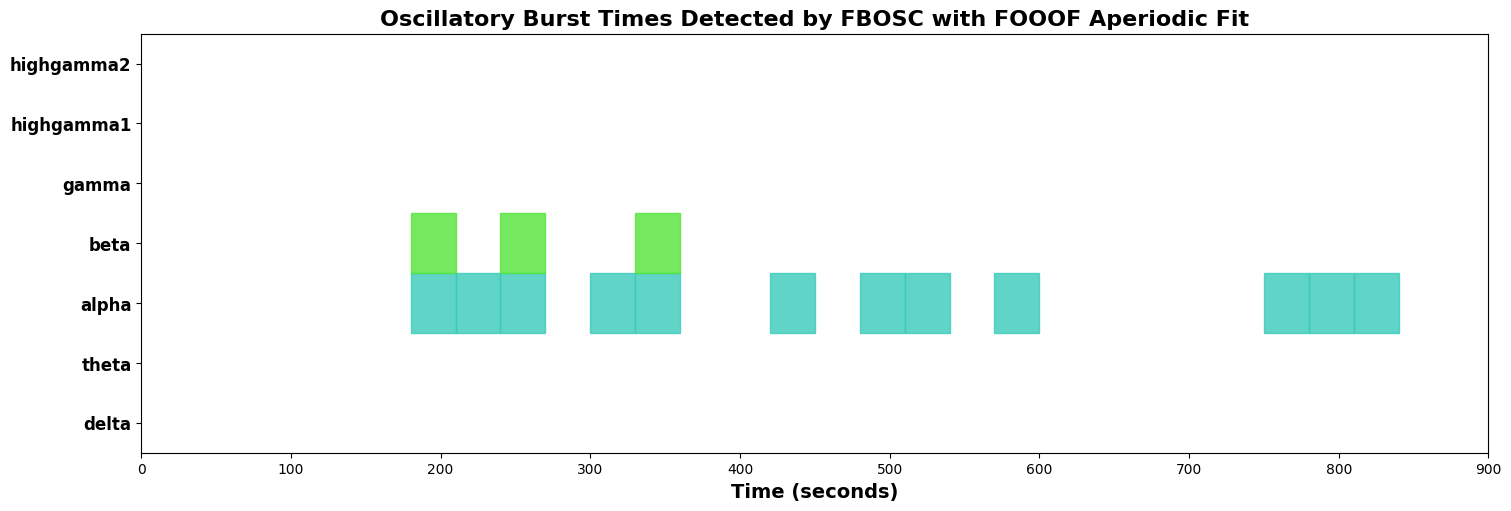

In [19]:
# plot oscillation times

# band colors
band_colors = {
    "delta": "#ad2bea",
    "theta": "#4d3ff8",
    "alpha": "#39cabb",
    "beta": "#53e53a",
    "gamma": "#e3e12c",
    "highgamma1": "#f7a740",
    "highgamma2": "#ed3838",
}

# fetch oscillatory burst times
band_names, oscillation_times = (analysis.FOOOFAnalysis.FBOSCAnalysis & key).fetch("band_name", "oscillation_times")
oscillation_dict = {}
for band_name in analysis.SpectralBand.fetch("band_name", order_by='lower_freq'):
    band_oscillation_times = oscillation_times[band_names == band_name][0]
    oscillation_dict[band_name] = band_oscillation_times

# create image plot marking oscillations as patches over time
fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
for i, (band_name, band_oscillation_times) in enumerate(oscillation_dict.items()):
    for oscillation in band_oscillation_times:
        ax.axvspan(oscillation-(dt/2), oscillation+(dt/2), ymin=i/len(oscillation_dict), ymax=(i+1)/len(oscillation_dict), color=band_colors[band_name], alpha=0.8)

# format plot
ax.set_yticks(np.arange(len(oscillation_dict)), labels=list(oscillation_dict.keys()), fontsize=12, fontweight='bold')
ax.set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')
ax.set_title('Oscillatory Burst Times Detected by FBOSC with FOOOF Aperiodic Fit', fontsize=16, fontweight='bold')
ax.set_xlim([0, T])
ax.set_ylim([-0.5, len(oscillation_dict)-0.5])

plt.show()